In [33]:
import matplotlib.pyplot as plt

from models.segment_break_detection.utils.dataset import BreakDataset
from models.segment_break_detection.utils.cnn_rnn import CNNRNN

DATA_DIR = '../../../data'
AUDIO_DIR = f'{DATA_DIR}/clean/audio/vocals'
LABEL_DIR = f'{DATA_DIR}/clean/segment_breaks'

# DATA_DIR = '../../../data_processing/separate_scripts'
# AUDIO_DIR = f'{DATA_DIR}/golden_audio'
# LABEL_DIR = f'{DATA_DIR}/golden_breaks'

INTERVAL_WIDTH = 20  # ms
NUM_CLASSES = 2  # 0: no break, 1: break

# Initialize the dataset
dataset = BreakDataset(audio_dir=AUDIO_DIR, label_dir=LABEL_DIR, interval_width=INTERVAL_WIDTH, include_index=True)

Loading dataset with include_index=True...


/home/eizigi/.local/share/virtualenvs/CS_541_Project-RTvQqKvc/lib/python3.10/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/home/eizigi/.local/share/virtualenvs/CS_541_Project-RTvQqKvc/lib/python3.10/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/home/eizigi/.local/share/virtualenvs/CS_541_Project-RTvQqKvc/lib/python3.10/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/home/eizigi/.local/share/virtualenvs/CS_541_Project-RTvQq

In [34]:
# Get the first example
file_idx, mel_spec, labels = dataset[0]

print(f'File index: {file_idx}')

File index: 0


In [35]:
# Get the a'th to b'th indices of the mel spectrogram and labels

# start_seconds = 12
# end_seconds = 15
# 
# a = int(start_seconds * 1000 / INTERVAL_WIDTH)
# b = int(end_seconds * 1000 / INTERVAL_WIDTH)
# 
# mel_spec = mel_spec[:, a:b]
# labels = labels[a:b]

# Plot the mel spectrogram with the labels overlayed on top (vertical line for any index that corresponds to label = 1 and nothing for label = 0)


In [36]:
# import matplotlib.pyplot as plt
# import librosa.display
# import numpy as np
# 
# def plot_spectrogram_with_labels(mel_spec, labels, start_seconds=None, end_seconds=None):
#     plt.figure(figsize=(12, 4))
# 
#     # Convert mel spectrogram to dB scale for better visualization
#     mel_spec_db = librosa.power_to_db(mel_spec.numpy(), ref=np.max)
# 
#     # Plot the mel spectrogram
#     librosa.display.specshow(
#         mel_spec_db,
#         y_axis='mel',
#         x_axis='time',
#         sr=1000/INTERVAL_WIDTH,  # Sample rate in frames per second
#         hop_length=1,  # Since we're already working with frames
#     )
# 
#     plt.colorbar(format='%+2.0f dB')
# 
#     # Add vertical lines for break points
#     break_indices = labels.nonzero(as_tuple=True)[0]
#     for idx in break_indices:
#         plt.axvline(x=idx * INTERVAL_WIDTH/1000, color='r', alpha=0.5, linestyle='--')
# 
#     # Set title and labels
#     window_text = f" ({start_seconds:.1f}s - {end_seconds:.1f}s)" if start_seconds is not None else ""
#     plt.title(f'Mel Spectrogram Window{window_text}')
#     plt.xlabel('Time (seconds)')
#     plt.ylabel('Mel Frequency Bins')
# 
#     plt.tight_layout()
#     return plt.gcf()
# 
# # Usage:
# fig = plot_spectrogram_with_labels(mel_spec, labels, start_seconds, end_seconds)
# plt.show()
# plt.close()


In [37]:
# min and max of mel
print(mel_spec.min(), mel_spec.max())

tensor(-1.3698) tensor(1.7498)


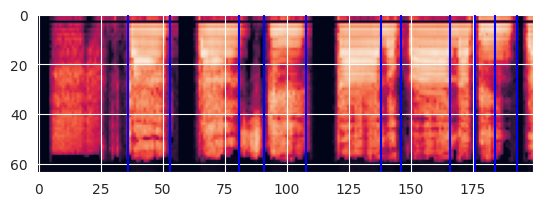

In [46]:
import matplotlib.pyplot as plt

# Get the slice
a = 600 # 580
b = 800 # 600
spec_slice = mel_spec[a:b, :].T
label_slice = labels[a:b]

# Plot the transposed spectrogram
plt.imshow(spec_slice)  # Transpose to show audio left-to-right

# Add red lines for label=1 positions
for i, label in enumerate(label_slice):
    if label == 1:
        plt.axvline(x=i, color='b')

plt.show()


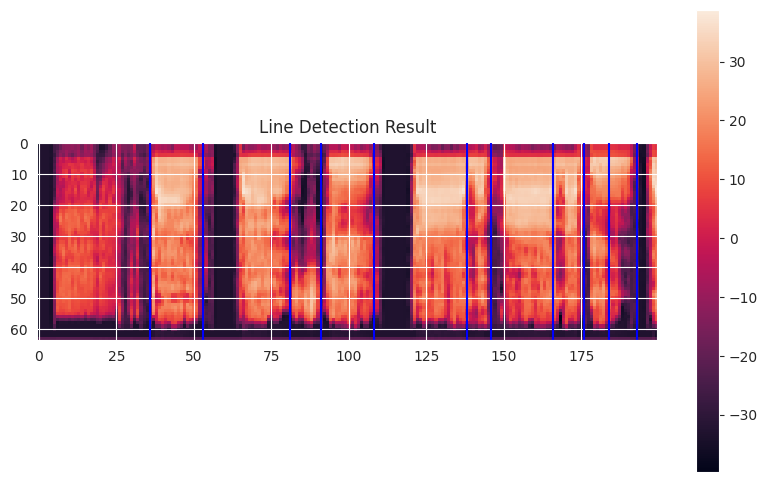

In [47]:
from scipy.signal import correlate2d
import numpy as np

mv = 10
kernel = np.array([[-1, mv, -1],
                   [-1, mv, -1],
                   [-1, mv, -1]])

processed_spec = correlate2d(spec_slice, kernel, mode='same')

plt.figure(figsize=(10,6))
plt.imshow(processed_spec)
plt.colorbar()
plt.title('Line Detection Result')

for i, label in enumerate(label_slice):
    if label == 1:
        plt.axvline(x=i, color='b')

plt.show()


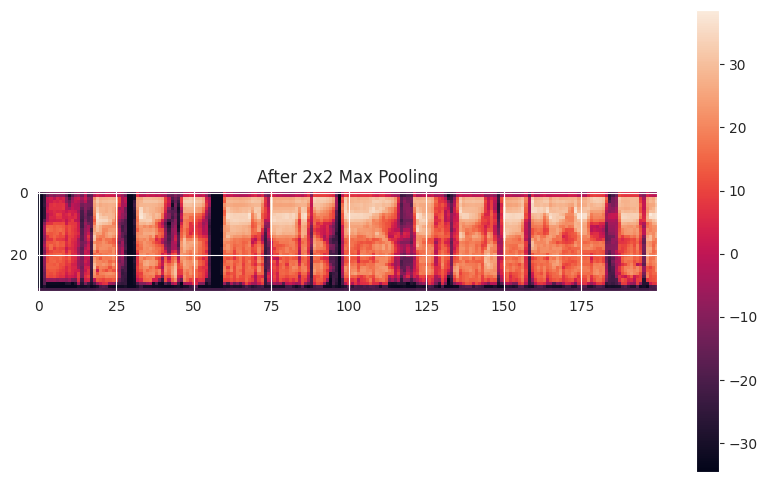

In [40]:
import numpy as np

def pool2x2(image):
    # Get dimensions
    h, w = image.shape
    # New dimensions after pooling
    new_h, new_w = h//2, w//2

    # Create output array
    pooled = np.zeros((new_h, new_w))

    # Perform 2x2 max pooling
    for i in range(new_h):
        for j in range(new_w):
            pooled[i,j] = np.max(image[2*i:2*i+2, 2*j:2*j+2])

    return pooled

# Apply pooling to the processed spectrogram
pooled_spec = pool2x2(processed_spec)

# Plot the result
plt.figure(figsize=(10,6))
plt.imshow(pooled_spec)
plt.colorbar()
plt.title('After 2x2 Max Pooling')
plt.show()


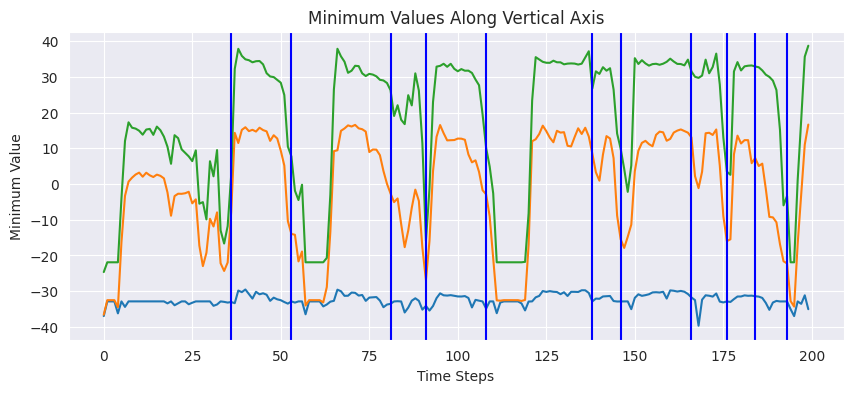

In [48]:
# Take minimum along vertical axis
min_values = np.min(processed_spec, axis=0)
median_values = np.median(processed_spec, axis=0)
mean_values = np.mean(processed_spec, axis=0)
max_values = np.max(processed_spec, axis=0)

# Plot the result
plt.figure(figsize=(10,4))
plt.plot(min_values)
#plt.plot(median_values)
plt.plot(mean_values)
plt.plot(max_values)
plt.title('Minimum Values Along Vertical Axis')
plt.xlabel('Time Steps')
plt.ylabel('Minimum Value')
plt.grid(True)

for i, label in enumerate(label_slice):
    if label == 1:
        plt.axvline(x=i, color='b')

plt.show()


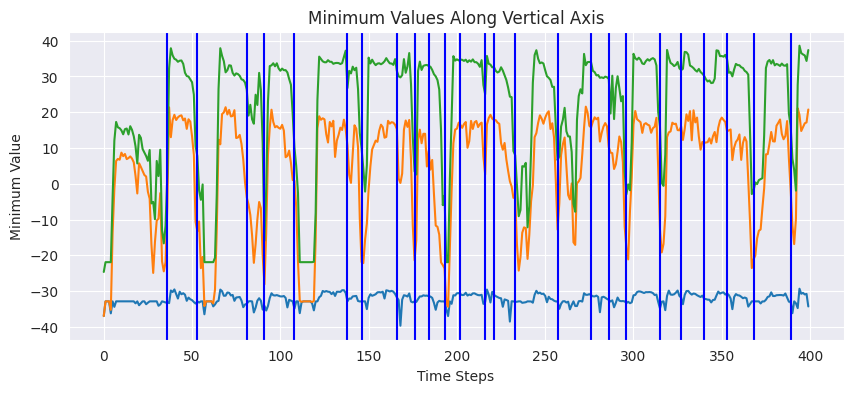

In [42]:
# Take minimum along vertical axis
min_values = np.min(processed_spec, axis=0)
median_values = np.median(processed_spec, axis=0)
max_values = np.max(processed_spec, axis=0)

# Plot the result
plt.figure(figsize=(10,4))
plt.plot(min_values)
plt.plot(median_values)
plt.plot(max_values)
plt.title('Minimum Values Along Vertical Axis')
plt.xlabel('Time Steps')
plt.ylabel('Minimum Value')
plt.grid(True)

for i, label in enumerate(label_slice):
    if label == 1:
        plt.axvline(x=i, color='b')

plt.show()


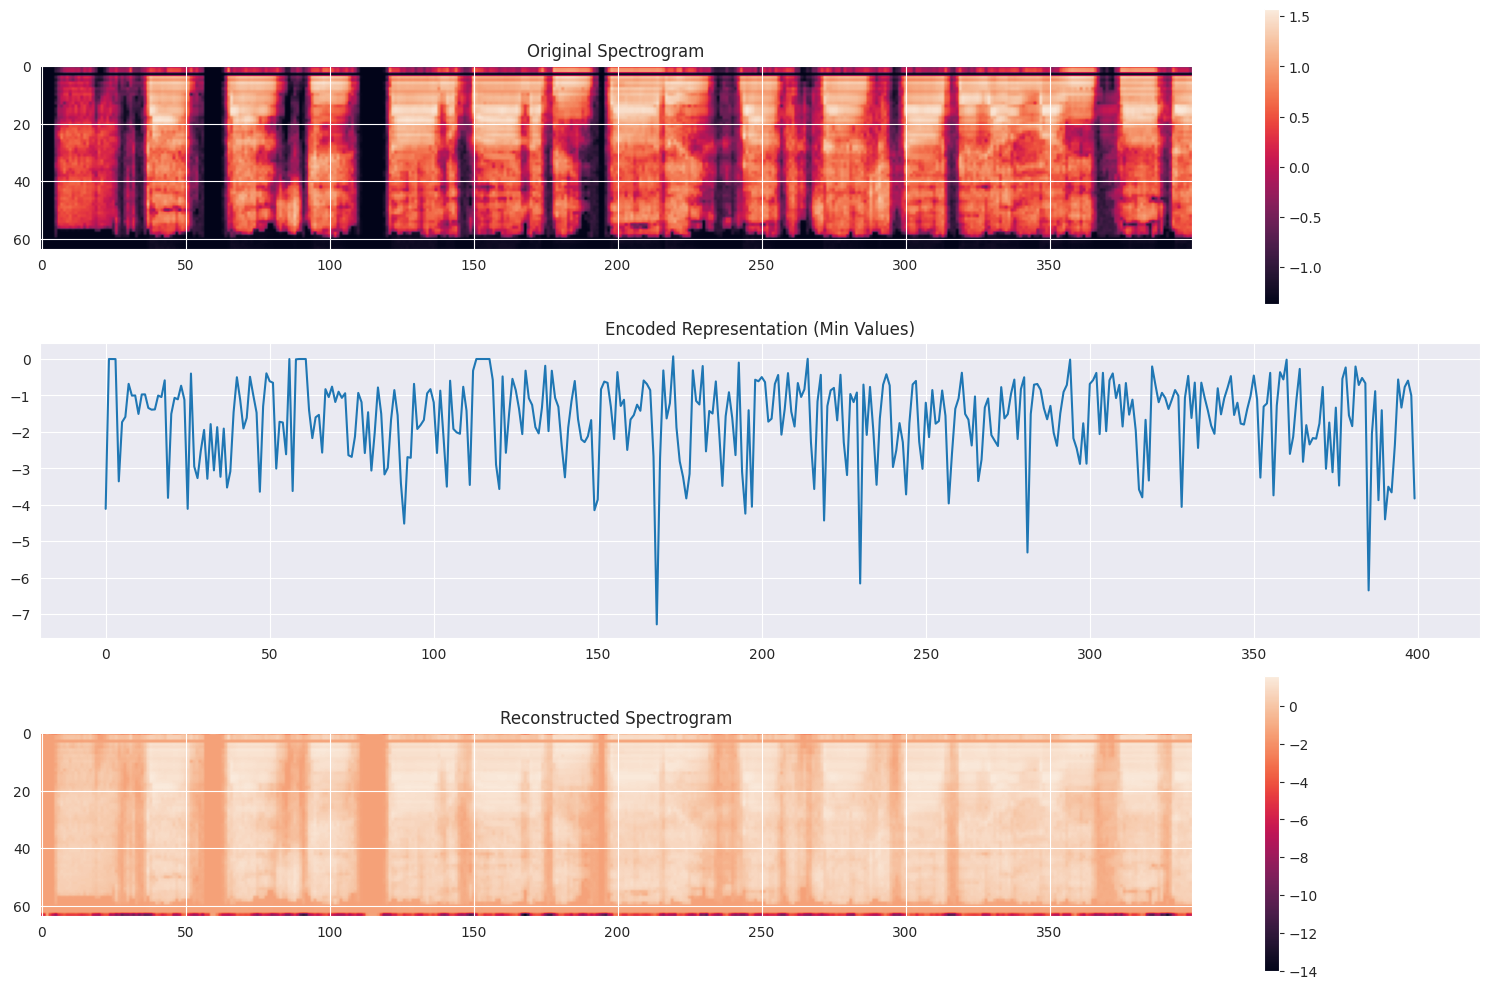

In [43]:
import numpy as np
from scipy.signal import correlate2d

class SpectrogramAutoencoder:
    def __init__(self):
        # Vertical line detection kernel
        self.kernel = np.array([[-1, 2, -1],
                                [-1, 2, -1],
                                [-1, 2, -1]])

    def encoder(self, x):
        # Store original input for skip connection
        self.original_input = x

        # Step 1: Apply 3x3 vertical line detection
        self.conv_output = correlate2d(x, self.kernel, mode='same')

        # Step 2: Take minimum along vertical axis
        self.encoded = np.min(self.conv_output, axis=0)

        return self.encoded

    def decoder(self, encoded):
        # Step 1: Expand back to 2D
        # Repeat the min values to match original height
        expanded = np.tile(encoded, (self.original_input.shape[0], 1))

        # Step 2: Apply transpose convolution (here simplified as correlation)
        # Make sure the kernel is properly transposed and reshaped
        decoded = correlate2d(expanded, self.kernel.T, mode='same')

        # Ensure shapes match before adding skip connection
        if decoded.shape != self.original_input.shape:
            # Resize decoded to match original input
            decoded = np.resize(decoded, self.original_input.shape)

        # Add skip connection from original input
        decoded = decoded + self.original_input

        return decoded

    def forward(self, x):
        # Ensure input is a 2D numpy array
        x = np.asarray(x)
        if x.ndim != 2:
            raise ValueError("Input must be a 2D array")

        # Full forward pass
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Create model
model = SpectrogramAutoencoder()

# Process spectrogram
processed_spec = model.forward(spec_slice)

# Visualize results
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.imshow(spec_slice)
plt.title('Original Spectrogram')
plt.colorbar()

plt.subplot(3, 1, 2)
plt.plot(model.encoded)
plt.title('Encoded Representation (Min Values)')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.imshow(processed_spec)
plt.title('Reconstructed Spectrogram')
plt.colorbar()

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import torch
import torch.nn as nn

class SpectrogramAutoencoder(nn.Module):
    def __init__(self, input_height, sequence_length, bottleneck_dim=16):
        super().__init__()
        self.input_height = input_height
        self.sequence_length = sequence_length
        self.bottleneck_dim = bottleneck_dim

        # Encoder
        self.vertical_conv = nn.Conv2d(1, 1, kernel_size=(3, 3), padding=1)
        self.encoder_linear = nn.Linear(input_height * sequence_length, bottleneck_dim)

        # Decoder
        self.decoder_linear = nn.Linear(bottleneck_dim, input_height * sequence_length)
        self.decoder_conv = nn.ConvTranspose2d(1, 1, kernel_size=(3, 3), padding=1)

    def encoder(self, x):
        # x shape: (batch_size, 1, height, sequence_length)
        x = self.vertical_conv(x)
        # Flatten
        x = x.view(x.size(0), -1)
        # Convert to small number of trainable parameters
        x = self.encoder_linear(x)
        return x

    def decoder(self, x):
        # Expand from bottleneck
        x = self.decoder_linear(x)
        # Reshape back to 2D
        x = x.view(x.size(0), 1, self.input_height, self.sequence_length)
        # Apply transpose conv
        x = self.decoder_conv(x)
        return x

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Custom loss function that incorporates both reconstruction and label overlay
class SpectrogramLoss(nn.Module):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.mse = nn.MSELoss()
        self.alpha = alpha  # Weight for label loss

    def forward(self, output, target, labels):
        # Basic reconstruction loss
        recon_loss = self.mse(output, target)

        # Label overlay loss
        label_loss = 0
        for b in range(output.size(0)):  # For each item in batch
            for i in range(output.size(-1)):  # For each time step
                if labels[b, i] == 1:
                    # Add loss to encourage higher values in columns where labels exist
                    label_loss += -torch.mean(output[b, :, :, i])

        return recon_loss + self.alpha * label_loss

# Training loop example
"""
# Initialize model
model = SpectrogramAutoencoder(
    input_height=spec_slice.shape[0], 
    sequence_length=spec_slice.shape[1]
).to(device)

# Initialize optimizer
optimizer = torch.optim.Adam(model.parameters())

# Initialize loss
criterion = SpectrogramLoss(alpha=0.1)

# Training loop
for epoch in range(num_epochs):
    model.train()
    for batch_specs, batch_labels in dataloader:
        # Move to device
        batch_specs = batch_specs.to(device)
        batch_labels = batch_labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        output = model(batch_specs)
        
        # Compute loss
        loss = criterion(output, batch_specs, batch_labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
    print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

# Visualization example
with torch.no_grad():
    model.eval()
    output = model(spec_tensor)
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 1, 1)
    plt.imshow(spec_slice)
    plt.title('Original Spectrogram')
    for i, label in enumerate(label_slice):
        if label == 1:
            plt.axvline(x=i, color='b')
    plt.colorbar()
    
    plt.subplot(2, 1, 2)
    plt.imshow(output[0, 0].cpu().numpy())
    plt.title('Reconstructed Spectrogram')
    for i, label in enumerate(label_slice):
        if label == 1:
            plt.axvline(x=i, color='b')
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()
"""


In [45]:
import torch
import torchaudio
from torch.utils.data import Dataset
import os
import pandas as pd
import numpy as np

class SpectrogramAutoencoderDataset(Dataset):
    def __init__(self,
                 audio_dir: str,
                 label_dir: str,
                 interval_width: int = 20,
                 debug: bool = False,
                 transform: callable = None):
        """
        Args:
        audio_dir: Directory containing audio files
        label_dir: Directory containing corresponding label CSV files
        interval_width: Width of fixed intervals for mel spectrogram (in ms)
        debug: If True, print debug statements
        transform: Optional transform to be applied to spectrograms
        """
        print("Loading Spectrogram Autoencoder Dataset...")
        self.audio_dir = audio_dir
        self.label_dir = label_dir
        self.interval_width = interval_width
        self.transform = transform
        self.data = []

        for audio_file in os.listdir(audio_dir):
            # Extract file index from filename
            file_idx = int(audio_file.split('.')[0])

            if debug:
                print(f"Processing file {file_idx}")

            # Check for corresponding label file
            label_path = os.path.join(label_dir, f"{file_idx}.csv")
            if not os.path.exists(label_path):
                if debug:
                    print(f"Skipping file {file_idx} - no label file")
                continue

            # Load labels
            df = pd.read_csv(label_path)
            labels = torch.tensor(df['break'].values, dtype=torch.float32)

            # Load and process audio
            waveform, sr = torchaudio.load(os.path.join(audio_dir, audio_file))
            mel_spec = self._compute_spectrogram(waveform, sr)

            # Truncate to last break + 2
            last_break = labels.nonzero(as_tuple=True)[0][-1]
            mel_spec = mel_spec[:last_break + 2, :]
            labels = labels[:last_break + 2]

            # Ensure shapes match
            assert mel_spec.shape[0] == labels.shape[0], \
                f"Mismatched shapes for file {file_idx}: {mel_spec.shape} vs {labels.shape}"

            # Optional transform
            if self.transform:
                mel_spec = self.transform(mel_spec)

            # Store data
            self.data.append({
                'spectrogram': mel_spec,
                'labels': labels,
                'file_idx': file_idx
            })

        print(f"Loaded {len(self.data)} samples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Return spectrogram, labels, and file index
        item = self.data[idx]
        return (
            item['spectrogram'].unsqueeze(0),  # Add channel dimension for Conv2d
            item['labels'],
            item['file_idx']
        )

    def _compute_spectrogram(self, waveform: torch.Tensor, sr: int) -> torch.Tensor:
        """
        Compute mel spectrogram from waveform.
        
        Args:
            waveform: Audio tensor from torchaudio.load
            sr: Sampling rate

        Returns: 
            Normalized mel spectrogram tensor with shape [n_frames, n_mels]
        """
        # Convert to mono
        waveform = waveform.mean(dim=0, keepdim=True)

        # Compute mel spectrogram
        mel_spec = torchaudio.transforms.MelSpectrogram(
            sample_rate=sr,
            hop_length=int(sr * self.interval_width / 1000),
            n_mels=64  # Adjustable mel band resolution
        )(waveform)

        # Process spectrogram
        mel_spec = mel_spec.squeeze(0)  # [n_mels, n_frames]
        mel_spec = torch.log(mel_spec + 1e-9)
        mel_spec = (mel_spec - mel_spec.mean()) / (mel_spec.std() + 1e-9)

        return mel_spec.T  # [n_frames, n_mels]

# Optional transform (if needed)
def custom_transform(spec):
    # Add any additional preprocessing
    return spec

# Create dataset
dataset = SpectrogramAutoencoderDataset(
    audio_dir=AUDIO_DIR,
    label_dir=LABEL_DIR,
    debug=True,
    transform=custom_transform
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(
    dataset, 
    batch_size=32, 
    shuffle=True
)

# Training loop (using previous SpectrogramAutoencoder)
model = SpectrogramAutoencoder(
    input_height=dataset[0][0].shape[2],  # height of spectrogram 
    sequence_length=dataset[0][0].shape[3]  # width of spectrogram
)

criterion = SpectrogramLoss()
optimizer = torch.optim.Adam(model.parameters())

for epoch in range(10):
    for specs, labels, file_idxs in dataloader:
        optimizer.zero_grad()
        output = model(specs)
        loss = criterion(output, specs, labels)
        loss.backward()
        optimizer.step()

Loading Spectrogram Autoencoder Dataset...
Processing file 0


/home/eizigi/.local/share/virtualenvs/CS_541_Project-RTvQqKvc/lib/python3.10/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


Processing file 10


/home/eizigi/.local/share/virtualenvs/CS_541_Project-RTvQqKvc/lib/python3.10/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


Processing file 11


...

Processing file 91


/home/eizigi/.local/share/virtualenvs/CS_541_Project-RTvQqKvc/lib/python3.10/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/home/eizigi/.local/share/virtualenvs/CS_541_Project-RTvQqKvc/lib/python3.10/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


Processing file 92
Processing file 9
Loaded 66 samples


/home/eizigi/.local/share/virtualenvs/CS_541_Project-RTvQqKvc/lib/python3.10/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


IndexError: tuple index out of range